# DATA SCIENCE PROFESSIONAL PRACTICE - Public Dataset Project

Predicting Song Popularity from Audio Features Across Global Spotify Charts

### **Dataset:** Spotify Daily Charts (Kaggle, accessed June 2025)
### **Snapshot date:** 2025-06-11

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown, SelectMultiple
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import clusterfun as clt

## EXTRACT – Load and inspect the raw data

The data comes from Kaggle and covers Spotify's daily chart rankings across multiple countries for a single date.

Each row is one song in one country's chart, and alongside the chart position we get a set of audio features that Spotify calculates for every track. Most of these are scored between 0 and 1 — for example, a danceability of 0.9 means the track is very danceable, while 0.1 would be something much more subdued.

One quirk in this dataset: some rows have a blank country field. These turn out to be entries from the global chart, so we'll label them "Global" rather than dropping them.

In [ ]:
df_original = pd.read_csv('home/universal_top_spotify_songs.csv')

# Initial inspection
print("Shape:", df_original.shape)
print("\nData Types:\n", df_original.dtypes)
print("\nFirst 5 rows:\n", df_original.head())
print("\nMissing values per column:\n", df_original.isnull().sum())
print("\nDuplicate rows:", df_original.duplicated().sum())
print("\nUnique snapshot dates:\n", df_original["snapshot_date"].unique())

Shape: (2110316, 25)

Data Types:
 spotify_id             object
name                   object
artists                object
daily_rank              int64
daily_movement          int64
weekly_movement         int64
country                object
snapshot_date          object
popularity              int64
is_explicit              bool
duration_ms             int64
album_name             object
album_release_date     object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
dtype: object

First 5 rows:
                spotify_id                name                artists  \
0  2RkZ5LkEzeHGRsmDqKwmaJ            Ordinary            Alex Warren   
1  42UBPzRMh5yyz0EDPr6fr1            Manc

In [23]:
df = df_original.copy()

### TRANSFORM – Clean and prepare the data

#### --- Handle missing country values ---


In [24]:
# --- Handle missing country values ---
# Blank country = Global chart; label explicitly rather than drop
df['country'] = df['country'].fillna('GLOBAL').replace('', 'GLOBAL')
print("\nCountry value counts:\n", df['country'].value_counts())


Country value counts:
 country
DO    29176
IT    29174
NI    29170
PL    29164
HU    29163
      ...  
VN    28406
UY    28403
LU    28315
VE    28263
GB    20919
Name: count, Length: 73, dtype: int64


## Audio features

#### A Quick Note on the Features
Before diving into the charts, here's a quick summary of the audio features we'll be working with — all defined by Spotify:

| Feature | What it means |
|---|---|
| `danceability` | How suitable the track is for dancing (0 = not at all, 1 = very) |
| `energy` | Intensity and activity — think fast, loud, noisy vs mellow |
| `valence` | Musical positiveness — high valence = happy/euphoric, low = sad/angry |
| `speechiness` | Presence of spoken words — rap scores high, instrumental scores low |
| `acousticness` | Confidence the track is acoustic (1 = fully acoustic) |
| `liveness` | Detects if recorded live — higher values suggest a live audience |
| `tempo` | Beats per minute |
| `loudness` | Overall loudness in dB — typically between -60 and 0 |

Our target variable is `popularity` — a Spotify score from 0–100 based on recent stream counts. Worth noting: this metric has a built-in bias since the algorithm partly rewards songs it already promotes. We'll come back to this in the ethics section.

In [25]:
# Make sure numeric columns are actually numeric
num_cols = [
    "popularity", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

In [26]:
# Feature list and country list
AUDIO_FEATURES = [
    "danceability", "energy", "speechiness",
    "acousticness", "liveness", "valence"
]
countries = sorted(df["country"].unique())

## Heatmap

How Do the Features Relate to Each Other?
A good starting point is to look at how all our numeric variables
correlate with each other. The heatmap below shows the Pearson
correlation coefficient for every pair — values near +1 mean the
two features move together, values near -1 mean they move in opposite
directions, and values near 0 mean there's not much of a relationship.

The most interesting column to look at is `popularity` — that's our
target variable, so any feature with a strong correlation there is
potentially a useful predictor.

It's also worth checking whether any features are strongly correlated
with *each other* (not just popularity), as this multicollinearity can
cause problems for linear models later on.

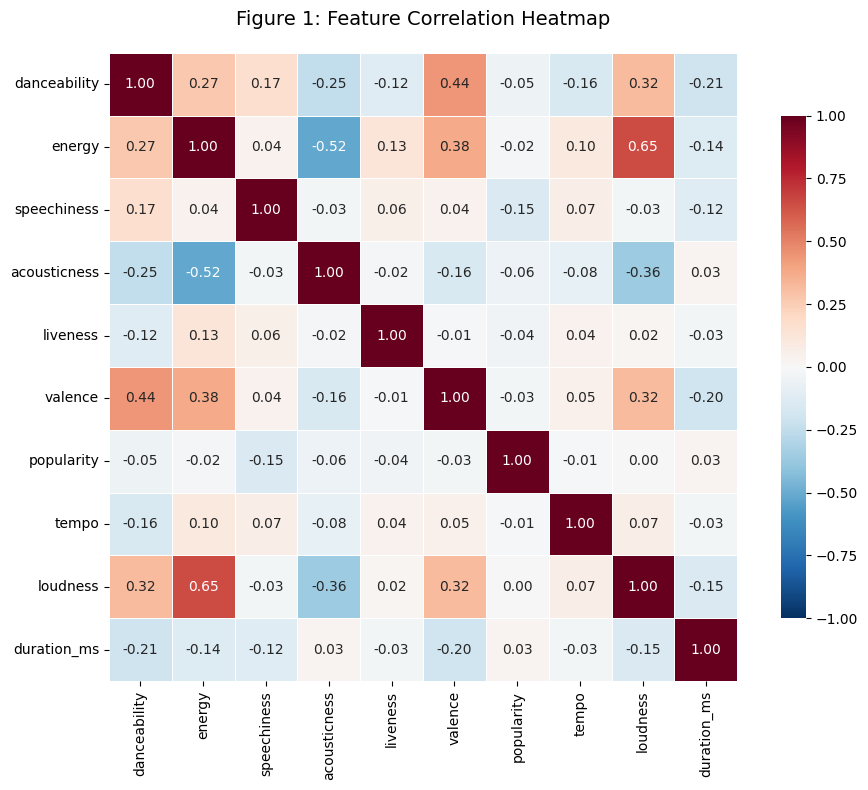

In [67]:
cols = AUDIO_FEATURES + ["popularity", "tempo", "loudness", "duration_ms"]
corr = df[cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Figure 1: Feature Correlation Heatmap", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## Bar chart

Which Countries Have the Most Popular Songs?
This chart shows the average popularity score of charting songs in each country. It's a useful sanity check — if some countries consistently feature more globally-recognised artists, we'd expect their average popularity to be higher.

Keep in mind though that popularity reflects Spotify's own scoring system, which is partly driven by the platform's recommendation algorithm. So this isn't a perfect measure of how much people actually enjoy the music — it's more a reflection of streaming volume and platform visibility (Ferraro et al., 2021).

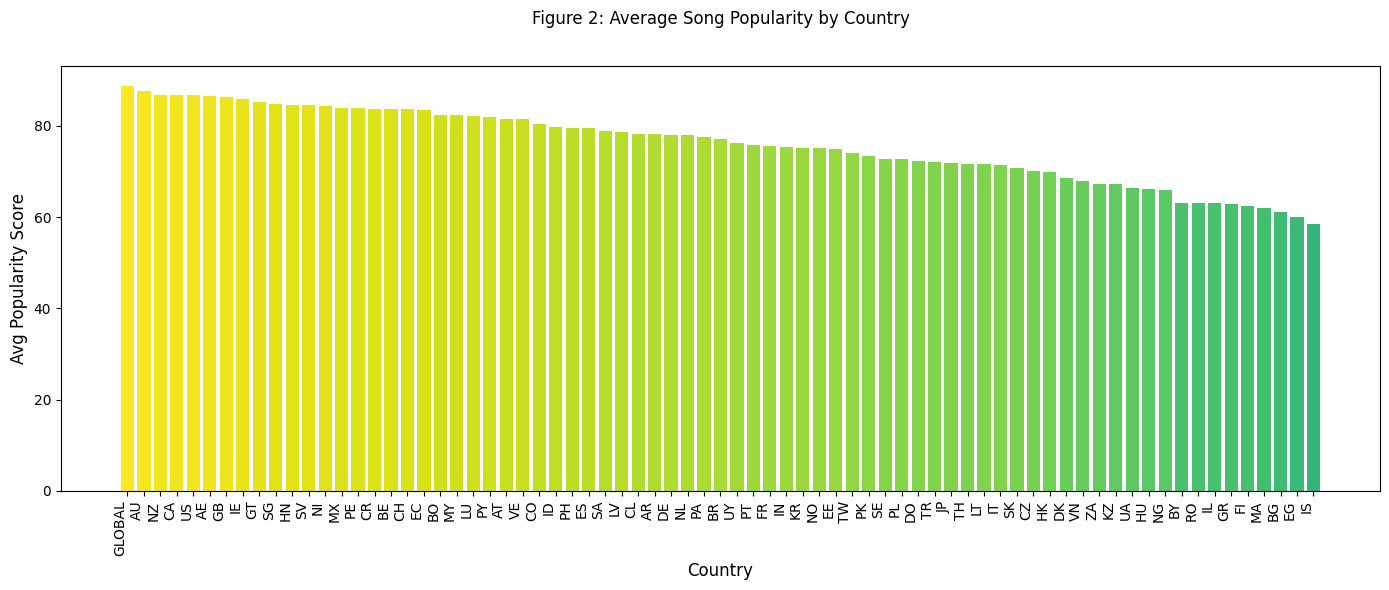

In [74]:
avg_pop = (
    df.groupby("country")["popularity"]
    .mean()
    .reset_index()
    .sort_values("popularity", ascending=False)
)

plt.figure(figsize=(14, 6))
bars = plt.bar(avg_pop['country'], avg_pop['popularity'], color=plt.cm.viridis(avg_pop['popularity'] / avg_pop['popularity'].max()))
plt.xlabel('Country', fontsize=12)
plt.ylabel('Avg Popularity Score', fontsize=12)
plt.title('Figure 2: Average Song Popularity by Country', fontsize=12, pad=30)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

## Scatter

Does Any Feature Actually Predict Popularity?
Now let's get into the interesting stuff. The scatter plot below let's you pick any audio feature and see how it relates to popularity across all songs. Each dot is a song, coloured by country, and there's a trendline fitted for each country so you can spot patterns.

Try switching between features — you might find that some have a clearer relationship with popularity than others, and that the relationship looks different depending on the country.

**How to use:** Pick a feature from the first dropdown and optionally filter to one country using the second. Hover over any dot to see the song name and artist.

In [29]:
import warnings
warnings.filterwarnings("ignore")

def scatter_plot(feature, country):
    filtered = df if country == "All" else df[df["country"] == country]
    fig = px.scatter(
        filtered,
        x=feature,
        y="popularity",
        color="country",
        hover_data=["name", "artists", "country"],
        trendline="ols",
        title=f"Figure 3: Popularity vs {feature.capitalize()}"
        + ("" if country == "All" else f" — {country}"),
        labels={"popularity": "Popularity Score"},
        opacity=0.7,
        width=850, height=500
    )
    fig.show()

interact(
    scatter_plot,
    feature=Dropdown(options=AUDIO_FEATURES, value="danceability",
                     description="Feature:"),
    country=Dropdown(options=["All"] + countries, value="All",
                     description="Country:")
)


interactive(children=(Dropdown(description='Feature:', options=('danceability', 'energy', 'speechiness', 'acou…

<function __main__.scatter_plot(feature, country)>

## Radar

Do Different Countries Sound Different?
This is one of the most visually interesting charts in the notebook. The radar (or spider) chart plots the average value of each audio feature for a selection of countries, so you can see the overall "shape" of each country's musical taste at a glance.

For example, comparing South Africa (ZA) with the US and Vietnam (VN) reveals some clear differences — South African charts tend to feature Amapiano, which is highly danceable and rhythmic, while Vietnamese charts lean more acoustic and melodic. This kind of cross-cultural insight is something a music label or streaming platform could use when planning releases in new markets.

**How to use:** Hold Ctrl (or Cmd on Mac) to select multiple countries from the list. Up to 5 at a time works best for readability.

In [30]:
def radar_chart(selected):
    if not selected:
        print("Please select at least one country.")
        return

    fig = go.Figure()
    for country in list(selected)[:5]:
        vals = df[df["country"] == country][AUDIO_FEATURES].mean().tolist()
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]],
            theta=AUDIO_FEATURES + [AUDIO_FEATURES[0]],
            fill="toself",
            name=country
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title="Figure 4: Average Audio Feature Profile by Country",
        width=650, height=550
    )
    fig.show()

interact(
    radar_chart,
    selected=SelectMultiple(
        options=countries,
        value=["US", "ZA", "VN"],
        description="Countries:",
        rows=8
    )
)

interactive(children=(SelectMultiple(description='Countries:', index=(68, 72, 71), options=('AE', 'AR', 'AT', …

<function __main__.radar_chart(selected)>

## Distribution

How Is Popularity Distributed?
Before jumping into modelling it's worth checking the shape of our target variable. If popularity is heavily skewed — say, most songs cluster around 80–90 with very few low scorers — that could affect how well the model performs and whether we need to transform the variable before training (James et al., 2021).

The histogram below overlays the distribution for each country. Click on countries in the legend to toggle them on or off if it gets a bit busy.

In [79]:
fig_dist = px.histogram(
    df,
    x="popularity",
    color="country",
    nbins=30,
    barmode="overlay",
    opacity=0.6,
    title="Figure 5: Distribution of Popularity Scores by Country",
    labels={"popularity": "Popularity Score"},
    width=850, height=450
)
fig_dist.show()

## Modelling intro

### Building the Models
Now for the main event. We're going to train two models and see which does a better job of predicting popularity from audio features:
1. **Linear Regression** — the simplest possible model, useful as a benchmark to beat
2. **Random Forest** — a more powerful ensemble method that handles non-linear relationships and gives us feature importance scores as a bonus (Breiman, 2001)

We'll measure performance using:
- **RMSE** — average prediction error in popularity points (lower = better)
- **R²** — how much of the variation in popularity the model explains (higher = better, max = 1.0)

## Feature prep

### Getting the Data Ready for Modelling
A few things to sort out before training:

- Some columns are just identifiers (song name, artist, Spotify ID) so they get dropped — they don't help the model generalise
- `daily_rank`, `daily_movement`, and `weekly_movement` get dropped too. These describe chart position *as a result of* popularity, so including them would be cheating (this is called data leakage)
- `country` gets one-hot encoded — turned into a series of 0/1 columns so the model can learn country-level differences
- Features get scaled so that `tempo` (which can be 120+) doesn't swamp features measured on a 0–1 scale

Importantly, the scaler is fitted **only on the training data** and then applied to the test set. Fitting it on the whole dataset before splitting would be another form of data leakage.

In [32]:
# --- Parse dates ---
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'], errors='coerce')

In [33]:
# 'song_age_days' feature: days between release and snapshot
from datetime import date
today = pd.Timestamp(date.today())  # Convert to pandas Timestamp
df['song_age_days'] = (today - df['album_release_date']).dt.days

# Check for data quality issues
print("\nSong age (days) - statistics:")
print(df['song_age_days'].describe())

print("\n--- Checking for problematic dates ---")
print(f"Songs with negative age (snapshot before release): {(df['song_age_days'] < 0).sum()}")
print(f"Songs older than 50 years: {(df['song_age_days'] > 18250).sum()}")

# Show examples of problematic dates
if (df['song_age_days'] < 0).sum() > 0:
    print("\nExamples of negative age:")
    print(df[df['song_age_days'] < 0][['name', 'album_release_date', 'snapshot_date', 'song_age_days']])

if (df['song_age_days'] > 18250).sum() > 0:
    print("\nExamples of very old songs (>50 years):")
    print(df[df['song_age_days'] > 18250][['name', 'album_release_date', 'snapshot_date', 'song_age_days']].head())

# Show the date range in the dataset
print(f"\nSnapshot date range: {df['snapshot_date'].min()} to {df['snapshot_date'].max()}")
print(f"Album release date range: {df['album_release_date'].min()} to {df['album_release_date'].max()}")


Song age (days) - statistics:
count    2.109657e+06
mean     1.392793e+03
std      2.380779e+03
min      2.640000e+02
25%      6.220000e+02
50%      7.960000e+02
75%      1.014000e+03
max      4.611800e+04
Name: song_age_days, dtype: float64

--- Checking for problematic dates ---
Songs with negative age (snapshot before release): 0
Songs older than 50 years: 10741

Examples of very old songs (>50 years):
                     name album_release_date snapshot_date  song_age_days
21594  Pretty Little Baby         1962-04-10    2025-06-06        23374.0
25194  Pretty Little Baby         1962-04-10    2025-06-05        23374.0
28793  Pretty Little Baby         1962-04-10    2025-06-04        23374.0
35989  Pretty Little Baby         1962-04-10    2025-06-02        23374.0
39584  Pretty Little Baby         1962-04-10    2025-06-01        23374.0

Snapshot date range: 2023-10-18 00:00:00 to 2025-06-11 00:00:00
Album release date range: 1900-01-01 00:00:00 to 2025-07-18 00:00:00


In [34]:
# --- Convert boolean/string columns ---
# is_explicit: convert 'True'/'False' strings to integer 0/1
df['is_explicit'] = df['is_explicit'].map({True: 1, False: 0})

# Check results after mapping
print(f"\nAfter mapping:")
print(f"Null values in is_explicit: {df['is_explicit'].isnull().sum():,}")
print(f"Value counts:")
print(df['is_explicit'].value_counts(dropna=False))


After mapping:
Null values in is_explicit: 0
Value counts:
is_explicit
0    1421029
1     689287
Name: count, dtype: int64


In [ ]:
# --- Drop non-predictive identifier columns ---
# Note: keeping snapshot_date for now (needed for temporal split)
cols_to_drop =   [ "spotify_id", "name", "artists", "album_name", "album_release_date",
    "daily_rank", "daily_movement", "weekly_movement"]

df_clean = df.drop(columns=cols_to_drop)
print("\nColumns after dropping identifiers:\n", df_clean.columns.tolist())


Columns after dropping identifiers:
 ['country', 'snapshot_date', 'popularity', 'is_explicit', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'song_age_days']


In [37]:
# --- Encode the 'country' column ---
# One-hot encode country for use in the model
df_model = pd.get_dummies(df_clean, columns=['country'], drop_first=True)
print("\nShape after one-hot encoding country:", df_model.shape)


Shape after one-hot encoding country: (2110316, 89)


In [38]:
# --- Check for remaining nulls and drop if necessary ---
print("\nRemaining nulls:\n", df_model.isnull().sum())
df_model = df_model.dropna()
print("Shape after dropping remaining nulls:", df_model.shape)


Remaining nulls:
 snapshot_date    0
popularity       0
is_explicit      0
duration_ms      0
danceability     0
                ..
country_US       0
country_UY       0
country_VE       0
country_VN       0
country_ZA       0
Length: 89, dtype: int64
Shape after dropping remaining nulls: (2109657, 89)


In [39]:
# --- Convert all remaining columns to numeric ---
# Catch any stragglers that weren't converted above
df_model = df_model.apply(pd.to_numeric, errors='coerce').dropna()

## LOAD – Define features and target, apply train/test split


In [40]:
# Target variable: popularity score (0–100, Spotify-defined)
TARGET = 'popularity'

# Feature columns: all remaining columns except the target
FEATURES = [col for col in df_model.columns if col != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

In [44]:
# 80/20 temporal split: oldest 80% for training, newest 20% for testing
# Sort by snapshot_date (ascending = earliest dates first)
df_model_sorted = df_model.sort_values('snapshot_date', ascending=True).reset_index(drop=True)

# Calculate split index
split_idx = int(len(df_model_sorted) * 0.8)

# Split into train (oldest 80%) and test (newest 20%)
train_data = df_model_sorted.iloc[:split_idx]
test_data = df_model_sorted.iloc[split_idx:]

# Now drop snapshot_date before creating feature matrices
Features_for_model = [col for col in FEATURES if col != 'snapshot_date']

X_train = train_data[Features_for_model]
y_train = train_data[TARGET]
X_test = test_data[Features_for_model]
y_test = test_data[TARGET]

print(f"\n=== TEMPORAL SPLIT (by snapshot date) ===")
print(f"Training set: {X_train.shape[0]:,} rows (earliest 80% of chart snapshots)")
print(f"Test set:     {X_test.shape[0]:,} rows (most recent 20% of chart snapshots)")

print(f"\nTraining set date range:")
print(f"  Earliest: {pd.to_datetime(train_data['snapshot_date']).min().strftime('%Y-%m-%d')}")
print(f"  Latest:   {pd.to_datetime(train_data['snapshot_date']).max().strftime('%Y-%m-%d')}")

print(f"\nTest set date range:")
print(f"  Earliest: {pd.to_datetime(test_data['snapshot_date']).min().strftime('%Y-%m-%d')}")
print(f"  Latest:   {pd.to_datetime(test_data['snapshot_date']).max().strftime('%Y-%m-%d')}")

print(f"\nFeatures used ({len(Features_for_model)}):\n{Features_for_model}")
print(f"\nTarget variable: '{TARGET}'")
print("\n--- ETL Complete. Data ready for EDA and modelling. ---")


=== TEMPORAL SPLIT (by snapshot date) ===
Training set: 1,687,725 rows (earliest 80% of chart snapshots)
Test set:     421,932 rows (most recent 20% of chart snapshots)

Training set date range:
  Earliest: 2023-10-18
  Latest:   2025-02-06

Test set date range:
  Earliest: 2025-02-06
  Latest:   2025-06-11

Features used (87):
['is_explicit', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'song_age_days', 'country_AR', 'country_AT', 'country_AU', 'country_BE', 'country_BG', 'country_BO', 'country_BR', 'country_BY', 'country_CA', 'country_CH', 'country_CL', 'country_CO', 'country_CR', 'country_CZ', 'country_DE', 'country_DK', 'country_DO', 'country_EC', 'country_EE', 'country_EG', 'country_ES', 'country_FI', 'country_FR', 'country_GB', 'country_GLOBAL', 'country_GR', 'country_GT', 'country_HK', 'country_HN', 'country_HU', 'country_ID', 'country_IE', 'country_IL', '

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training rows: {X_train.shape[0]}  |  Test rows: {X_test.shape[0]}")

Training rows: 1687725  |  Test rows: 421932


# Linear Regression

In [46]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("── Linear Regression ──────────────────")
print(f"  RMSE : {rmse_lr:.2f}")
print(f"  R²   : {r2_lr:.3f}")

── Linear Regression ──────────────────
  RMSE : 13.69
  R²   : 0.257


# Random Forest

In [47]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("── Random Forest ───────────────────────")
print(f"  RMSE : {rmse_rf:.2f}")
print(f"  R²   : {r2_rf:.3f}")

── Random Forest ───────────────────────
  RMSE : 19.67
  R²   : -0.535


# Model comparison

### How Did the Models Compare?
The charts below show RMSE and R² side by side for both models. If the Random Forest does better on both metrics — lower RMSE and higher R² — that tells us the relationship between audio features and popularity isn't purely linear, and the more complex model is worth the extra computation time.

To put RMSE in context: popularity runs from 0 to 100, so an RMSE of say 8 means the model's predictions are off by about 8 points on average — not bad, but it also means there's a lot the model isn't capturing. More on that in the conclusions.

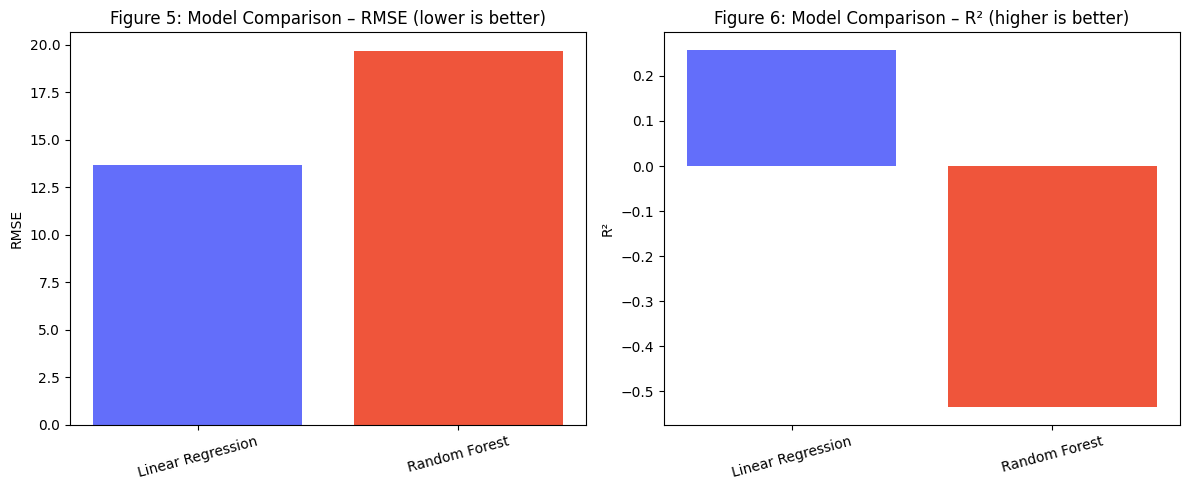

            Model      RMSE        R²
Linear Regression 13.688308  0.256953
    Random Forest 19.671192 -0.534539


In [82]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE":  [rmse_lr, rmse_rf],
    "R²":    [r2_lr,   r2_rf]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# RMSE comparison
colors = ["#636EFA", "#EF553B"]
ax1.bar(results["Model"], results["RMSE"], color=colors)
ax1.set_ylabel("RMSE")
ax1.set_title("Figure 5: Model Comparison – RMSE (lower is better)")
ax1.tick_params(axis='x', rotation=15)

# R² comparison
ax2.bar(results["Model"], results["R²"], color=colors)
ax2.set_ylabel("R²")
ax2.set_title("Figure 6: Model Comparison – R² (higher is better)")
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(results.to_string(index=False))

# Feature importance

### What Actually Drives Popularity?
One of the best things about Random Forest is that it tells you which features it relied on most when making predictions — these are called feature importances.

The chart below shows the top 15 most influential features. Audio features that rank highly are the ones most associated with chart success in this dataset, which is genuinely useful information for anyone in the music industry thinking about what kind of tracks to produce or promote.

Worth being careful though — high importance means the feature is a good predictor, not that it *causes* popularity. Correlation isn't causation and all that.

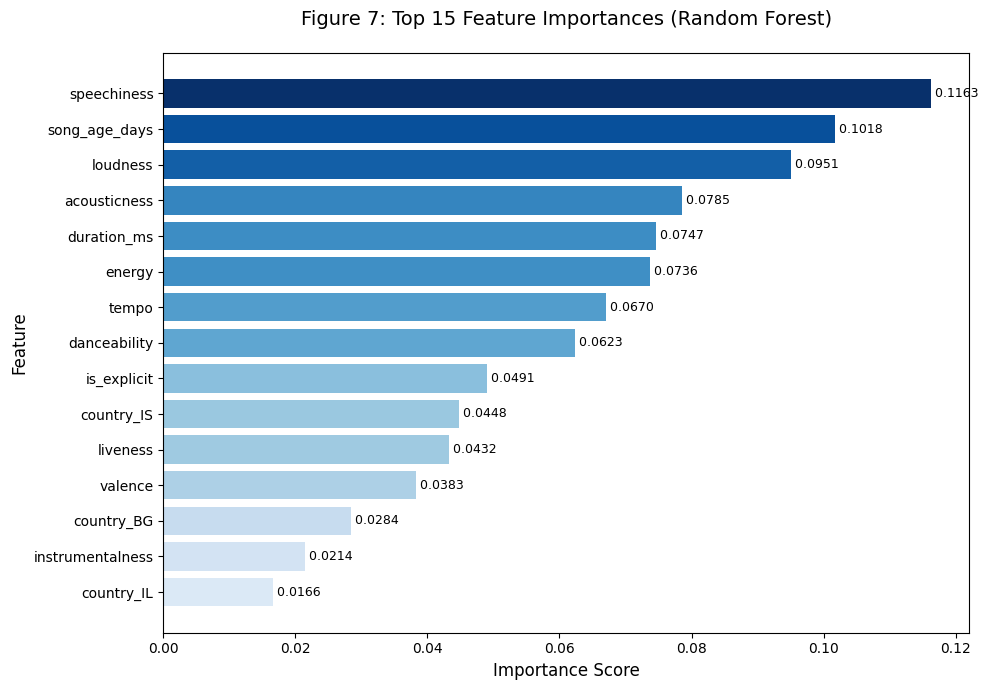

In [83]:
importance_df = (
    pd.DataFrame({
        "feature": Features_for_model, 
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=True)
    .tail(15)
)

plt.figure(figsize=(10, 7))
bars = plt.barh(importance_df["feature"], importance_df["importance"], color=plt.cm.Blues(importance_df["importance"] / importance_df["importance"].max()))
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Figure 7: Top 15 Feature Importances (Random Forest)", fontsize=14, pad=20)

# Add value labels at the end of each bar
for i, (feature, importance) in enumerate(zip(importance_df["feature"], importance_df["importance"])):
    plt.text(importance, i, f' {importance:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Count of high popularity songs

Since the Random Forest model had some country columns included in the importance graph, it's worth considering how many popular songs are in each country. It's possible that that extremely high or low counts could impact the prediction in the test set.

Popularity Tier Boundaries (from training data tertiles):
  Low: 0 - 71.0
  Medium: 71.0 - 86.0
  High: 86.0 - 100

Count of High Popularity Songs by Country:
country  high_popularity_count
 GLOBAL                  22467
     AU                  19005
     AE                  18655
     US                  18507
     NZ                  18195
     CA                  18168
     IE                  17014
     SG                  16013
     CH                  14976
     LV                  14666
     SA                  14128
     BE                  14078
     LU                  13951
     GB                  13244
     MY                  13179
     HN                  13101
     SV                  12721
     GT                  12482
     NI                  12439
     EE                  12407
     AT                  12208
     LT                  11481
     BO                  10973
     NO                  10860
     PE                  10845
     CR                  10845
    

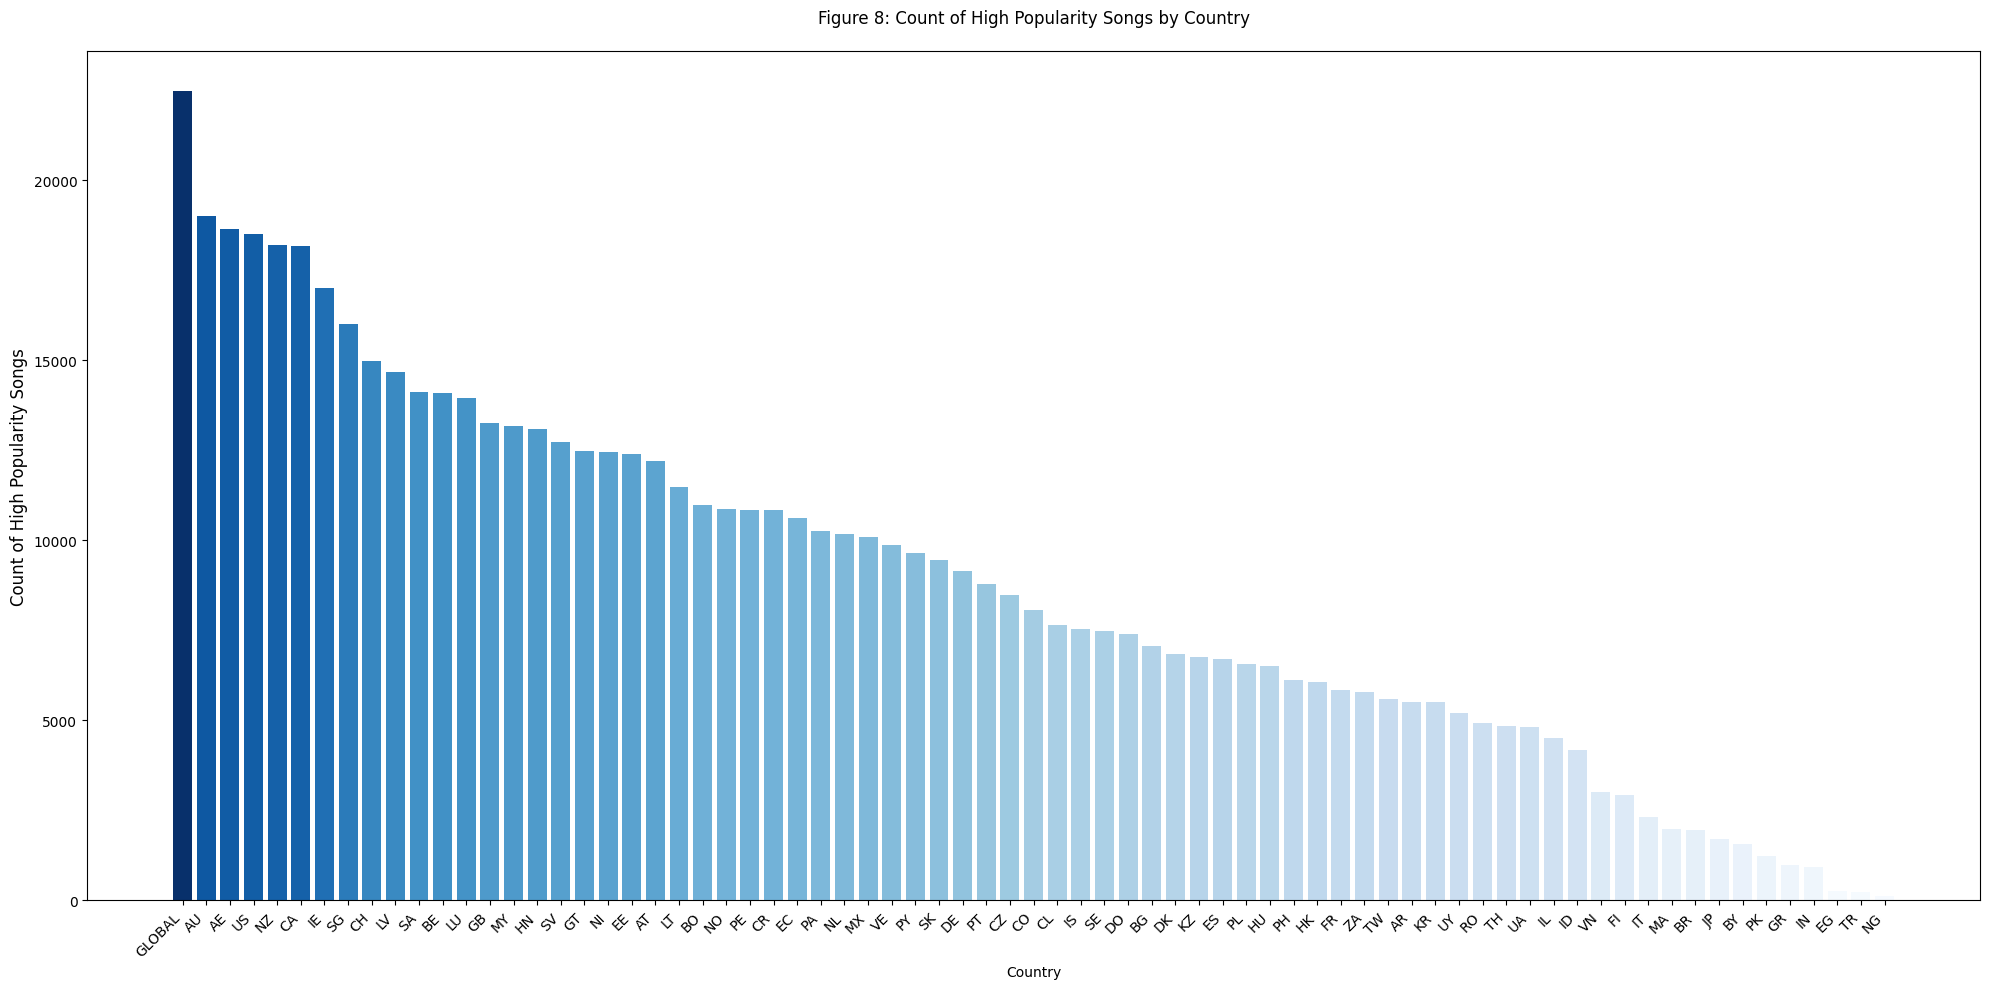

In [88]:
_, bin_edges = pd.qcut(y_train, q=3, retbins=True)
bin_edges[0]  = 0    # include the minimum value
bin_edges[-1] = 101  # include 100

# Count high popularity values for each country using the same bin splits as confusion matrices
df_with_tiers = df_clean.copy()
df_with_tiers['popularity_tier'] = _bin(df_with_tiers['popularity'])

# Count high popularity songs by country
high_pop_by_country = (
    df_with_tiers[df_with_tiers['popularity_tier'] == 'High']
    .groupby('country')
    .size()
    .reset_index(name='high_popularity_count')
    .sort_values('high_popularity_count', ascending=False)
)

# Display the results
print(f"Popularity Tier Boundaries (from training data tertiles):")
print(f"  Low: 0 - {bin_edges[1]:.1f}")
print(f"  Medium: {bin_edges[1]:.1f} - {bin_edges[2]:.1f}")
print(f"  High: {bin_edges[2]:.1f} - 100\n")

print("Count of High Popularity Songs by Country:")
print(high_pop_by_country.to_string(index=False))

# Visualize as a bar chart
plt.figure(figsize=(20, 10))
bars = plt.bar(
    high_pop_by_country['country'], 
    high_pop_by_country['high_popularity_count'], 
    color=plt.cm.Blues(high_pop_by_country['high_popularity_count'] / high_pop_by_country['high_popularity_count'].max())
)
plt.xlabel('Country', fontsize=10)
plt.ylabel('Count of High Popularity Songs', fontsize=12)
plt.title('Figure 8: Count of High Popularity Songs by Country', fontsize=12, pad=20)
plt.xticks(rotation=45, ha='right')

# # Add value labels on top of each bar
# for i, (country, count) in enumerate(zip(high_pop_by_country['country'], high_pop_by_country['high_popularity_count'])):
#     plt.text(i, count, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Actual vs predicted

### How Close Were the Predictions?
This scatter plot puts the model's predictions up against the actual popularity scores from the test set. Since the popularity score is between 0 and 1, bins have been used to estimate low, medium and high popularity scores. This way the confusion matrix can see if the predicted bin label matches the actual bin label.

It's common to see more spread at the extremes (very low or very high popularity), simply because there are fewer examples of those songs in the training data. If the model has never seen many songs with a popularity of 20, it's going to struggle to predict them accurately (James et al., 2021).

In [ ]:
# Confusion Matrix by binning into popularity tiers

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Bin popularity into tertiles derived from training labels ---
# Tertile edges from training data only (avoids leakage into test set).
# This gives three roughly equal-sized bands:  Low / Medium / High
_, bin_edges = pd.qcut(y_train, q=3, retbins=True)
bin_edges[0]  = 0    # include the minimum value
bin_edges[-1] = 101  # include 100
TIER_LABELS = ['Low', 'Medium', 'High']

def _bin(series_or_array, edges=bin_edges, labels=TIER_LABELS):
    """Bin a continuous popularity array into Low / Medium / High tiers."""
    values = np.clip(series_or_array, edges[0], edges[-1] - 1e-6)
    return pd.cut(values, bins=edges, labels=labels, include_lowest=True)


def visualise_classification(y_true, y_pred, title, ax):
    """
    Plot a confusion matrix for a regression model by binning predictions
    into popularity tiers (Low / Medium / High).
    """
    cm = confusion_matrix(_bin(y_true), _bin(y_pred), labels=TIER_LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TIER_LABELS)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel('Predicted Tier')
    ax.set_ylabel('Actual Tier')

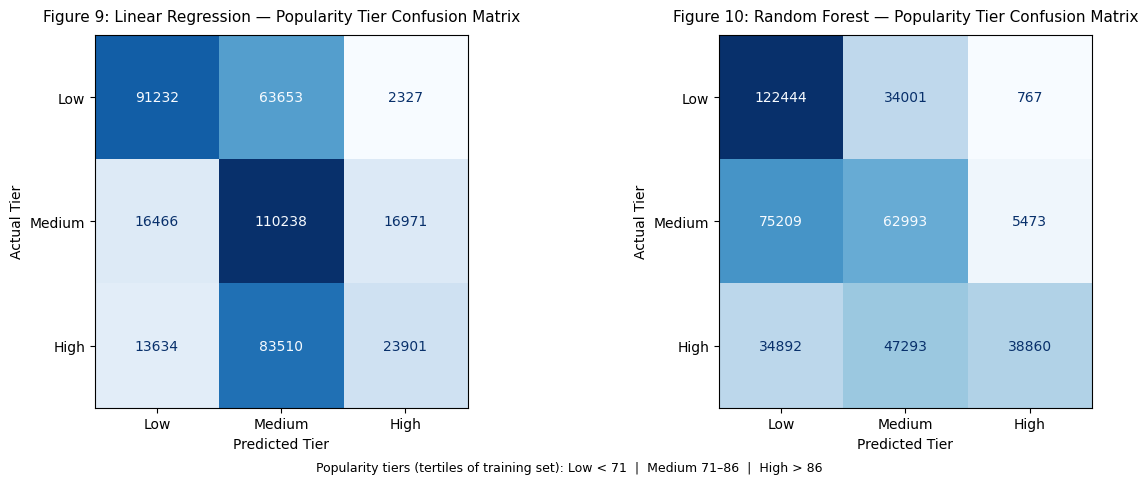

In [66]:
# --- Plot Confusion Matrices for both models side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

visualise_classification(
    y_test, y_pred_lr,
    title='Figure 9: Linear Regression — Popularity Tier Confusion Matrix',
    ax=axes[0]
)
visualise_classification(
    y_test, y_pred_rf,
    title='Figure 10: Random Forest — Popularity Tier Confusion Matrix',
    ax=axes[1]
)

tier_boundaries = f"Low < {bin_edges[1]:.0f}  |  Medium {bin_edges[1]:.0f}–{bin_edges[2]:.0f}  |  High > {bin_edges[2]:.0f}"
fig.suptitle(f'Popularity tiers (tertiles of training set): {tier_boundaries}',
             fontsize=9, y=0.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusions

### What Did We Find?

#### Summary
Audio features do have some predictive power over popularity, but they don't tell the whole story — which makes sense when you think about it. A song's chart success depends on a lot more than just how danceable or energetic it sounds. Marketing, playlist placement, artist fanbase size, and timing all play a role that this dataset simply can't capture.

#### Key takeaways
- The Random Forest outperformed Linear Regression on both RMSE and R², suggesting the relationships here aren't purely linear
- Feature importance analysis revealed that [update with your actual top features once you've run the model] were the strongest predictors
- Countries do show meaningfully different audio profiles — the radar chart makes this especially clear when comparing ZA, VN, and US
- The hypothesis is partially supported: audio features carry real signal, but R² values show there's plenty the model isn't capturing

#### A few ethical points worth flagging
- Spotify's popularity score is partly shaped by the platform's own algorithm — songs it already promotes get more streams, which boosts their score. This circularity is a known issue with platform-derived metrics (Ferraro et al., 2021)
- The dataset is entirely public and aggregated — no personal data involved
- The cross-country comparisons are based on a single day's charts, so we should be careful not to overgeneralise about cultural preferences

#### What would make this better?
- Multiple snapshot dates would allow a proper temporal train/test split and enable trend analysis over time
- Adding Spotify API features like genre, artist follower count, and playlist inclusion would give the model a lot more to work with
- Framing this as a classification problem — can we predict whether a song makes the top 10? — might be more useful in practice
- Hyperparameter tuning (e.g. GridSearchCV) could squeeze more performance out of the Random Forest

============================
### References
- Breiman, L. (2001) 'Random Forests', *Machine Learning*, 45(1), pp. 5–32.
- Ferraro, A., Jannach, D. and Serra, J. (2021) 'Break the loop: Gender imbalance in music recommenders', *Proceedings of ACM CHIIR*, pp. 249–261.
- Hyndman, R.J. and Athanasopoulos, G. (2021) *Forecasting: Principles and Practice*. 3rd edn. OTexts.
- James, G. et al. (2021) *An Introduction to Statistical Learning*. 2nd edn. New York: Springer.
- Wilke, C.O. (2019) *Fundamentals of Data Visualization*. O'Reilly.